## Running hello_mujoco.py

`mujoco` is installed in the project's `.venv`, but the notebook's kernel may be pointing at a different Python (e.g. system Python 3.13) which doesn't have it. Fix by switching kernels:

1. Click the kernel picker in the top-right corner of the notebook (it probably shows something like "Python 3.13.x").
2. Choose **Select Another Kernel** → **Python Environments** → pick the one at `MyCode/.venv/bin/python` (shows as something like `.venv (Python 3.x)`).
3. Re-run your cells.

Once the kernel is set correctly, run the script with:

```python
%run hello_mujoco.py
```


In [5]:
%run hello_mujoco.py

MuJoCo version: 3.9.0
Model has 2 bodies, 7 qpos DOFs
Ball start pos: [0. 0. 1.]
Ball pos after 1s (should have fallen): [ 0.  -0.   0.1]


## Visualize the environment

Offscreen-render frames of the falling ball to confirm the physics and rendering pipeline both work.

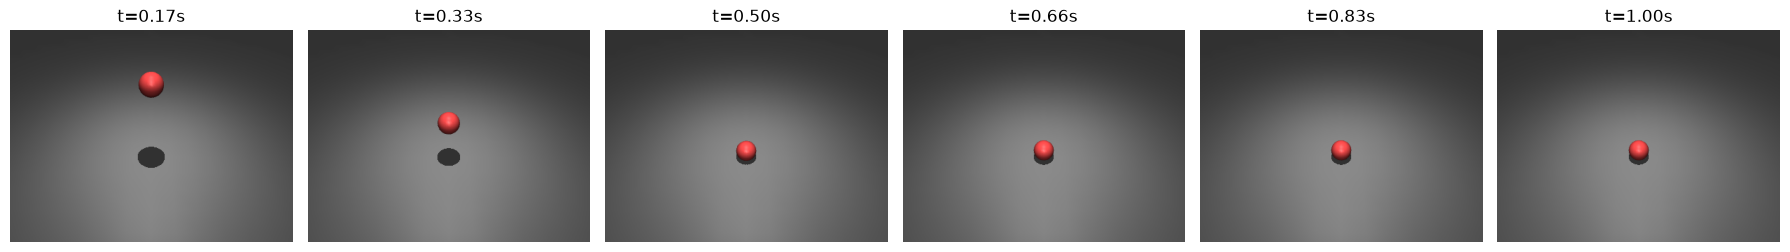

In [7]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt

# Same model as hello_mujoco.py
xml = """
<mujoco>
  <worldbody>
    <light pos="0 0 3"/>
    <geom type="plane" size="5 5 0.1"/>
    <body pos="0 0 1">
      <freejoint/>
      <geom type="sphere" size="0.1" rgba="1 0.3 0.3 1"/>
    </body>
  </worldbody>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=300, width=400)

n_frames = 6
steps_per_frame = int((1.0 / model.opt.timestep) / n_frames)

frames = []
for _ in range(n_frames):
    for _ in range(steps_per_frame):
        mujoco.mj_step(model, data)
    renderer.update_scene(data)
    frames.append(renderer.render())

fig, axes = plt.subplots(1, n_frames, figsize=(3 * n_frames, 3))
for ax, frame, i in zip(axes, frames, range(n_frames)):
    ax.imshow(frame)
    ax.set_title(f"t={ (i + 1) * steps_per_frame * model.opt.timestep:.2f}s")
    ax.axis("off")
plt.tight_layout()
plt.show()

renderer.close()